In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from wordcloud import WordCloud, ImageColorGenerator
from PIL import Image

In [57]:
df=pd.read_csv('compressed_captions.csv')

df1=df['caption'].reset_index()
df1=df1.rename(columns = {'index':'dexnum'})

#..ponieważ index zaczynał się od 0, to dexnum będzie od index+1
df1['dexnum']=df1['dexnum']+1
df1['caption']=df1['caption'].str.split()

#.. używamy biblioteki re aby usunać wszelkie znaki niebędące literami, cyframi, podkreśleniami (\w) ani białymi znakami (spacje, tabulacje, nowe linie - \s)
df1['caption'] = df1['caption'].apply(lambda row: [re.sub(r'[^\w\s]', '', x).lower() for x in row]) 

#..zależy nam na słowach dłuższych niż 3, by uniknąć nadmiaru spójników, zaimków, artykułów gramatycznych (a,the) w wordcloud
df1['caption'] = df1['caption'].apply(lambda x: [word for word in x if len(word) > 3])
df1

,dexnum,caption
0,1,"[small, amphibian, pokémon, bluegreen, skin, w..."
1,2,"[ivysaur, short, rounded, snout, with, wide, m..."
2,3,"[squat, quadrupedal, amphibian, pokémon, bumpy..."
3,4,"[bipedal, reptilian, pokémon, with, primarily,..."
4,5,"[dark, scales, cream, underside, from, chest, ..."
...,...,...
1020,1021,"[massive, quadrupedal, yellow, sauropodlike, p..."
1021,1022,"[spherical, bulllike, pokémon, coated, reflect..."
1022,1023,"[luminous, head, yellow, metal, horns, similar..."
1023,1024,"[small, reptilian, pokémon, resembles, indigo,..."


In [58]:
#.. .explode() rozbija listę w kolumnie caption na osobne wiersze
df_words_all = df1.explode('caption')
df_words_all = df_words_all.reset_index(drop=True)

#..zliczamy pojawienia się danych słów
counts_cap=df_words_all['caption'].value_counts()

#..ręcznie pomijamy popularne angielskie spójniki, zaimki nieniosące ze sobą większego znaczenia
counts_cap=counts_cap.drop(['with','also','this','there','than','them','that','each','which','have','into','over','either'])
counts_cap

caption
pokémon       810
body          489
eyes          423
head          416
black         375
             ... 
metang          1
cannot          1
discshaped      1
joint           1
semicirc        1
Name: count, Length: 3069, dtype: int64

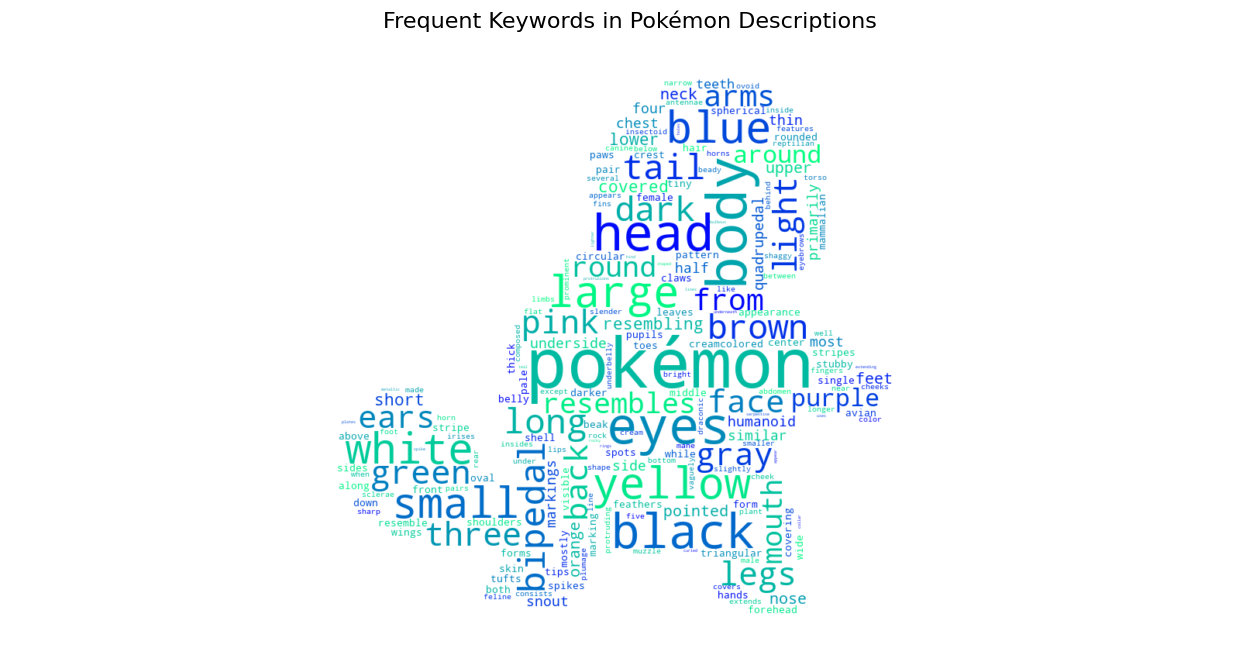

In [59]:
#..za pomocą Image.open() otwieramy plik, a następnie przekształcamy go do array
mask = np.array(Image.open("canva3.png"))

#..przekształcamy dataframe do słownika
freq_dict=counts_cap.to_dict()

chmura=WordCloud(
    background_color='white',
    mask=mask,
    colormap='winter',
    width=1600,
    height=800
)
chmura.generate_from_frequencies(freq_dict)
plt.figure(figsize=(16,9))
plt.imshow(chmura, interpolation='bilinear')
plt.axis('off')

plt.title('Frequent Keywords in Pokémon Descriptions', fontsize=16)
plt.savefig('wordcloud.png')
plt.show()